# Classical Error Correction

In [1]:
%pip install -e ~/deltakit-textbook

Looking in links: /usr/share/pip-wheels
Obtaining file:///home/f73aeabd-6de4-471d-92a9-1ba552ae6153/deltakit-textbook
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for deltakit-textbook (pyproject.toml) ... done
  Created wheel for deltakit-textbook: filename=deltakit_textbook-0.0.0-0.editable-py3-none-any.whl size=4827 sha256=b901a9b2384ec7d44b012ed845ebee3c801aace667fca893e72611572841ad45
  Stored in directory: /tmp/pip-ephem-wheel-cache-ge0b7cc0/wheels/5d/bd/f8/449a5f5525755c7915b059424bb229b7b46fd90882998f3811
Successfully built deltakit-textbook
  Attempting uninstall: deltakit-textbook
    Found existing installation: deltakit-textbook 0.0.0
    Uninstalling deltakit-textbook-0.0.0:
      Successfully uninstalled deltakit-textbook-0.0.0
Note: you may need to restart the kernel to use updated packages.

In [2]:
import random
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Monospace'
import math
import qec #Local package 

## <font color='blue'>A classical error correction scenario</font>

Imagine two parties (a sender and a receiver) communicating across a noisy channel. The effect of the noisy channel is to corrupt the communication between the two parties by introducing an error.

The sender transmits one bit (0 or 1) of information at a time, and the receiver gets each of those bits on the other side, but the noisy channel flips some of them from 0 to 1 (or vice versa). 

To overcome the errors caused by the noisy channel, they agree on the simplest error-correcting protocol: let's repeat the same message multiple times. The receiver then takes a majority vote of all the repeated bits to determine what the original message was. In error correction terminology, the two parties are communicating using a repetition code, with code distance equal to the number of times the message is copied/repeated.

Below, we write three functions to capture the communication between the two parties. The `encode` function creates `num_copies` copies of one `bit` of information. This is the message that the sender intends to transmit. Then, the `send` function takes those `bits`, and corrupts some of them with probability `p_error` by flipping them from 0 to 1 (or vice versa). Finally, the `receive_and_interpret` function takes in those `bits` and, depending on whether the `majority_vote` flag is set, returns either a single bit that won the majority vote, or the count of how many 0 and 1 bits were received.

In [3]:
message = qec.repetition_codes.encode(1, 5)
print(message)

[1, 1, 1, 1, 1]


We can then transmit this message across a noisy channel by writing

In [4]:
transmitted = qec.repetition_codes.send(message, 0.1)
print(transmitted)

[1, 1, 1, 1, 1]


And finally, we can interpret what these bits could have meant by writing

In [5]:
received = qec.repetition_codes.receive_and_interpret(transmitted)
print(received)

[(1, 5)]


where we see how many 0s and 1s were received, or take a majority vote by writing

In [6]:
received = qec.repetition_codes.receive_and_interpret(transmitted, majority_vote = True)
print(received)

1


## <font color='blue'>Measuring the effectiveness of classical repetition codes</font>

Now, let's ask the following question: how well does this duplicate-and-take-majority-vote scheme work?

To do this, we run several iterations (`n_shots`) where we send a randomly picked message across the channel to see when we can successfully recover the desired message. We will count the number of times we are unable to recover the desired message, and report it as a probability in `n_shots` attempts.

We will try several code distances, i.e. the number of repeated copies of each bit, to see the impact of increased redundancy on error correction. Note that we are only using odd-numbered distances $(1,3,5,\ldots)$ so that we can ensure that majority voting works.

In [7]:
code_distances = np.arange(start = 1, stop = 21, step = 2)
p_errors = np.logspace(start = -3, stop = 0, num = 50)

all_code_distance_error_probabilities = []
for code_distance in code_distances:
    print(f"Running distance {code_distance}")
    code_distance_error_probabilities = []
    for p_error in p_errors:
        code_distance_error_probabilities.append(
            qec.repetition_codes.get_code_error_probability(code_distance, p_error, 100000)
        )
    all_code_distance_error_probabilities.append(code_distance_error_probabilities)

Running distance 1
Running distance 3
Running distance 5
Running distance 7
Running distance 9
Running distance 11
Running distance 13
Running distance 15
Running distance 17
Running distance 19


Now, we can plot the results to see the effectiveness of the error-correcting scheme.

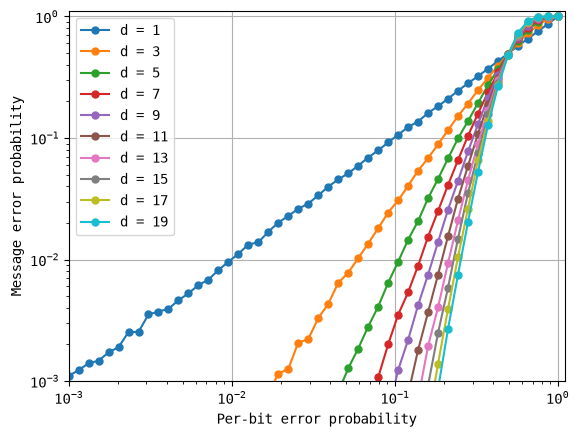

In [8]:
for code_distance, error_probabilities in zip(code_distances, all_code_distance_error_probabilities):
    plt.loglog(p_errors, error_probabilities, marker = '.', markersize = 10, label=f'd = {code_distance}')
plt.legend()
plt.xlabel('Per-bit error probability')
plt.ylabel('Message error probability')
plt.xlim([1e-3, 1.1])
plt.ylim([1e-3, 1.1])
plt.grid()
plt.show()

First, note that code distance `d = 1` has no effect on the message. When the probability of error introduced by the channel (the x-axis labeled per-bit error probability) is $10^{-2}$, so is the probability of error of the encoded message (the y-axis labeled message error probability). However, for larger distances, a reduction in the per-bit error probability leads to steeper reductions in the error of the encoded message. For example, at distance $3$, the same per-bit error probability leads to an error in the received message that is well below $10^{-3}$, a 10x improvement.

To see the effect of error correction more clearly, we take a vertical slice of the above plot for a specific value of per-bit error probability, and see what happens at various code distances.

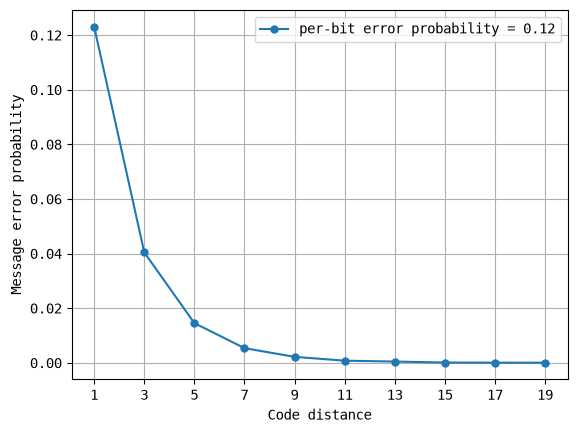

In [9]:
specific_p_error = 0.12
idx = np.searchsorted(p_errors, specific_p_error, side="left")
message_error_probabilities_for_p_error = [all_code_distance_error_probabilities[i][idx] for i in range(len(code_distances))]
plt.plot(code_distances, message_error_probabilities_for_p_error, marker = '.', markersize = 10, label = f'per-bit error probability = {specific_p_error}')
plt.xlabel('Code distance')
plt.ylabel('Message error probability')
plt.xticks(code_distances)
plt.legend()
plt.grid()
plt.show()

As you can see, increasing code distances result in an exponential suppression of the per-bit error. For the specific value of `p_error = 0.12`, the error of the message being misinterpreted is already down 3x at code distance 3, and $\sim8$x at code distance 5.

## <font color='blue'>The presence of a threshold</font>

The astute reader may have noticed in the above plots that error correction makes things worse (and not better) when the per-bit error is large. We can see this more clearly by replotting as shown below.

In [10]:
code_distances = np.arange(start = 1, stop = 21, step = 2)
p_errors = np.linspace(start = 0.1, stop = 1, num = 10)

all_code_distance_error_probabilities = []
for code_distance in code_distances:
    print(f"Running distance {code_distance}")
    code_distance_error_probabilities = []
    for p_error in p_errors:
        code_distance_error_probabilities.append(qec.repetition_codes.get_code_error_probability(code_distance, p_error, 100000))
        
    all_code_distance_error_probabilities.append(code_distance_error_probabilities)

Running distance 1
Running distance 3
Running distance 5
Running distance 7
Running distance 9
Running distance 11
Running distance 13
Running distance 15
Running distance 17
Running distance 19


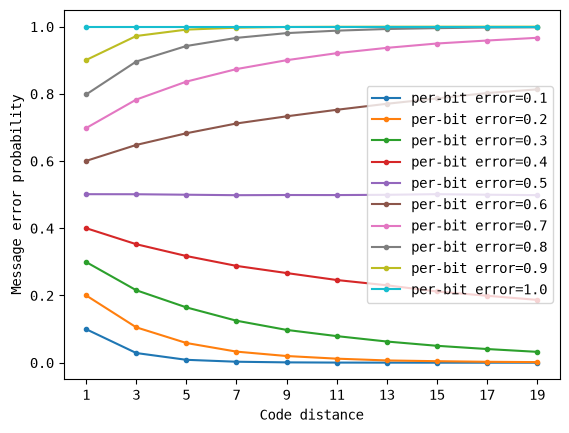

In [11]:
for ii in range(0, len(p_errors), 1):
    error_probabilities = [all_code_distance_error_probabilities[j][ii] for j in range(len(code_distances))]
    plt.plot(code_distances, error_probabilities, marker = '.', label=f'per-bit error={p_errors[ii]:.1f}')
plt.xticks(code_distances)
plt.legend()
plt.xlabel('Code distance')
plt.ylabel('Message error probability')
plt.show()

As you can see above, as the per-bit error probability crosses $0.5$, the effect of our error correction scheme flips. When the noisy channel is simply too noisy (and therefore the per-bit error probability is larger than $0.5$), error correction doesn't help at all -- in fact, it makes things worse because each redundantly added bit is unlikely to help the situation. However, when the noisy channel is good enough (with a per-bit error probability less than $0.5$), the benefits of our error correction scheme appear clearly, resulting in an improvement in chance of success that the received message is interpreted successfully. The specific value of the per-bit error probability where the effect of error correction flips sharply is known as the _threshold_. From an engineering standpoint, we want to create a noisy channel that is at least that good, so that we can employ error correction and achieve low overall errors.

## <font color='blue'>The challenge of correlated errors</font>

So far, the kind of error mechanism we simulated was a random flip of each bit, independently of what happens to all other bits. In the language of statistics, this is known as an _independent, identially distributed_ (i.i.d.) noise model -- each bit in the repetition code has no "knowledge" of what happened to all the others, and experiences the error independently on its own.

Error correction can handle these kinds of errors easily using schemes like the repetition code. However, when there is some correlation in the way that the bits experience the noise -- for example, two bits will always flip at the same time -- then the effectiveness of a repetition code is limited. In this section, we will demonstrate this effect by writing down two noise models and running the same simulations above.

The correlated noise model that we will use is inspired by experimental observations of error bursts due to cosmic rays (see McEwen et al,  [arxiv:2104.05219](https://arxiv.org/abs/2104.05219)). When these events occur (sometimes due to energy impacts from cosmic rays), the quantum processor experiences errors across all qubits. We will model this scenario as follows: with a small probability $p_\text{correlated}$, all bits in our repetition code will flip. Otherwise, each of the bits will flip independently as before with probability $p_\text{error}$.

In [ ]:
code_distances = [3, 7, 13]
p_errors = np.logspace(start = -6, stop = 0, num = 30)
p_correlated = 2e-4

In [ ]:
all_code_distance_error_probabilities_random_iid = []
for code_distance in code_distances:
    print(f"Running distance {code_distance}")
    code_distance_error_probabilities_random_iid = []
    for p_error in p_errors:
        code_distance_error_probabilities_random_iid.append(qec.logical_error.get_code_error_probability_random_iid(code_distance, p_error, 200000))
        
    all_code_distance_error_probabilities_random_iid.append(code_distance_error_probabilities_random_iid)

all_code_distance_error_probabilities_correlated = []
for code_distance in code_distances:
    print(f"Running distance {code_distance}")
    code_distance_error_probabilities_correlated = []
    for p_error in p_errors:
        code_distance_error_probabilities_correlated.append(qec.logical_error.get_code_error_probability_correlated(code_distance, p_error, p_correlated, 200000))
    all_code_distance_error_probabilities_correlated.append(code_distance_error_probabilities_correlated)

In [ ]:
colors = plt.cm.viridis(np.linspace(0, 0.8, len(code_distances)))

for color, code_distance, error_probabilities_random_iid, error_probabilities_correlated in zip(colors, code_distances, all_code_distance_error_probabilities_random_iid, all_code_distance_error_probabilities_correlated):
    plt.loglog(p_errors, error_probabilities_random_iid, marker = '.', markersize = 12, label=f'd={code_distance}, all i.i.d.', color = color)
    plt.loglog(p_errors, error_probabilities_correlated, marker = 'd', markersize = 7, label=fr'd={code_distance}, $2\times10^{{-4}}$ correlated else i.i.d.', color = color)
plt.loglog(p_errors, p_errors, linestyle = '--', linewidth = 2, label='no error correction', color = 'gray')
plt.legend()
plt.xlabel('Per-bit error probability')
plt.ylabel('Message error probability')
plt.xlim([1e-5, 1.1])
plt.ylim([1e-5, 1.1])
plt.grid()
plt.show()

As you can see above, even small amounts of correlated errors that break the indepedent, identically distributed noise model assumption can lead to a catastrophic outcome. No matter how low the error of flipping individual bits gets, the benefit of error correction remains limited to a level determined by the correlated errors. Perhaps more importantly, no matter how large of a code distance we go to, the logical error probability never gets lower, highlighting that deploying "more" error correction by increasing the size of the repetition code does not help. The only way out is to resolve the cause of the error bursts, or to shield from them in the experimental setting when possible. For the specific example discussed above with superconducting qubits, the authors have identified one solution that resists high-energy impacts by modifying the fabrication techniques of the processors (see McEwen et al, [arXiv:2402.15644](https://arxiv.org/abs/2402.15644)).

**Exercise for the reader**

We used the majority vote decoder to interpret the received message above. This decoder only works when $p < 0.5$ such that most bits remain unflipped. When $p > 0.5$, there exists another decoder that works. Can you identify that decoder? How would you modify the majority vote decoder to implement it? 

In [ ]:
code_distance = 5
p_values = np.linspace(0.0, 1.0, 501)

majority_errors = [qec.logical_error.majority_decoder_error_probability(code_distance, p) for p in p_values]
adaptive_errors = [qec.logical_error.adaptive_decoder_error_probability(code_distance, p) for p in p_values]

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(p_values, majority_errors, linewidth=2.5, label="Ordinary majority decoder" )
ax.plot(p_values, adaptive_errors, linewidth=2.5, label="Adaptive decoder: majority/minority")
ax.plot(p_values, p_values, linestyle=":", color="gray", linewidth=2, label="Unprotected bit")
ax.axvline(0.5, linestyle="--", color="black", linewidth=1.5, label=r"Threshold $p=0.5$")
ax.scatter( [0.5], [0.5], color="black", zorder=5)
ax.annotate( "Channel contains no information", xy=(0.5, 0.5), xytext=(0.57, 0.63), arrowprops={"arrowstyle": "->"})
ax.text(0.22, 0.9, "Use majority vote", ha="center")
ax.text(0.78, 0.9, "Use minority vote", ha="center")

ax.set(
    title=f"Majority and Minority Decoding for Distance {code_distance}",
    xlabel="Physical bit-flip probability, $p$",
    ylabel="Logical error probability, $p_L$",
    xlim=(0, 1),
    ylim=(0, 1),
)

ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show() 

<details>
    <summary>Easter egg</summary>
    The first plot in this chapter (message error probability vs per-bit error probability) appears on the cover page of the textbook. However, note that the plot on the cover has a y-axis that extends to the $10^{-9}$ (part-per-billion) range. Doing this requires taking a few billion shots of statistics. This takes a lot of time to do, but you will learn the techniques to speed up these simulations later in this textbook (see the chapter on running faster circuit simulations).
</details>